# EE473 Final Project: Energy-Aware Edge Scheduling with Reinforcement Learning

Zilong Zeng & Meng Wu


## 1) Problem Setup

We model edge scheduling as a sequential decision problem with three actions: `low`, `medium`, and `high`.
At each step, workload arrives from trace data. The chosen action controls service and energy use, then queue and battery states are updated.

Reward:
`r_t = -(alpha_energy * energy_t + beta_latency * latency_t + gamma_miss * miss_t)`

Default weights: `(alpha, beta, gamma) = (1.0, 0.6, 2.0)`.

## 2) Dataset and Evaluation Protocol

- Source: Google cluster task-event trace (`120` shards)
- Preprocess: aggregate submit events, normalize workload, split train/test
- Episode length: `288`
- Main protocol: `20` train episodes + `6` non-overlap test episodes
- Methods: heuristic baselines, tabular Q-learning, linear approximation Q-learning
- Reporting: 5 seeds with mean/std

## 3) Environment Setup

The following cell loads the trace, constructs train/test episodes, and initializes the simulation environment used by all methods.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
assert (ROOT / 'scripts').exists(), f'Expected repo root at {ROOT}'
print('ROOT =', ROOT)

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import DEFAULT_ENV_CONFIG
from data_loader import load_workload_trace, build_episodes
from env import EnergySchedulingEnv

TRACE_PATH = ROOT / 'data/processed/workload_trace_120.csv'
EPISODE_LENGTH = 288
STRIDE = 288

train_series = load_workload_trace(TRACE_PATH, split='train')
test_series  = load_workload_trace(TRACE_PATH, split='test')

train_episodes = build_episodes(train_series, EPISODE_LENGTH, stride=STRIDE)[:20]
test_episodes  = build_episodes(test_series,  EPISODE_LENGTH, stride=STRIDE)[:6]

print(f"Train episodes : {len(train_episodes)}  ×  {len(train_episodes[0])} steps")
print(f"Test  episodes : {len(test_episodes)}  ×  {len(test_episodes[0])} steps")
print(f"Workload range : [{min(train_series):.3f}, {max(train_series):.3f}]")

ROOT = /Users/zilongzeng/Documents/EE473final project
Train episodes : 20  ×  288 steps
Test  episodes : 6  ×  288 steps
Workload range : [0.000, 1.000]


## 4) Baseline Evaluation

We first evaluate fixed policies (`always_low`, `always_medium`, `always_high`, threshold rules) on held-out test episodes.

In [2]:
import pandas as pd
from baselines import (
    always_low_policy, always_medium_policy, always_high_policy,
    threshold_policy_factory, evaluate_policy,
)

baseline_policies = {
    'always_low': always_low_policy,
    'always_medium': always_medium_policy,
    'always_high': always_high_policy,
    'threshold(w=0.60)': threshold_policy_factory(workload_threshold=0.60),
    'threshold(w=0.80)': threshold_policy_factory(workload_threshold=0.80),
}

baseline_results = {}
rows = []
for name, policy in baseline_policies.items():
    m = evaluate_policy(test_episodes, policy, config=DEFAULT_ENV_CONFIG)
    baseline_results[name] = m
    rows.append({
        'Policy': name,
        'Avg Return': round(m['avg_episode_return'], 3),
        'Energy': round(m['avg_step_energy'], 4),
        'Latency': round(m['avg_step_latency'], 4),
        'Miss Rate': round(m['miss_rate'], 4),
    })

baseline_df = pd.DataFrame(rows).sort_values('Avg Return', ascending=False).reset_index(drop=True)
display(baseline_df)

,Policy,Avg Return,Energy,Latency,Miss Rate
0,always_low,-57.289,0.1800,0.0315,0.0
1,threshold(w=0.80),-57.390,0.1951,0.0069,0.0
2,threshold(w=0.60),-58.512,0.2022,0.0016,0.0
3,always_medium,-121.749,0.4200,0.0046,0.0
4,always_high,-244.800,0.8500,0.0000,0.0


## 5) RL Training (Single-Seed Sanity Check)

We run tabular Q-learning and linear approximation Q-learning once to verify that training works end-to-end.
Final claims are based on the 5-seed results in the next section.

In [3]:
import time
from q_learning import QLearningConfig, train_tabular_q_learning

# Tabular Q-learning
tabular_cfg = QLearningConfig(
    num_epochs=300,
    alpha=0.15,
    gamma=0.98,
    epsilon_start=0.30,
    epsilon_end=0.02,
    epsilon_decay=0.995,
    eval_every=5,
    seed=42,
)

t0 = time.perf_counter()
tabular_result = train_tabular_q_learning(
    train_episodes=train_episodes,
    test_episodes=test_episodes,
    env_config=DEFAULT_ENV_CONFIG,
    algo_config=tabular_cfg,
)
tabular_time = time.perf_counter() - t0

print(f"Tabular Q-learning  —  training time: {tabular_time:.2f} s")
bm = tabular_result['best_test_metrics']
print(f"  Best checkpoint (epoch {int(tabular_result['best_epoch'])}):")
print(f"    avg_return = {bm['avg_episode_return']:.4f}")
print(f"    energy     = {bm['avg_step_energy']:.4f}")
print(f"    latency    = {bm['avg_step_latency']:.4f}")
print(f"    miss_rate  = {bm['miss_rate']:.4f}")

Tabular Q-learning  —  training time: 6.70 s
  Best checkpoint (epoch 115):
    avg_return = -56.2166
    energy     = 0.1878
    latency    = 0.0123
    miss_rate  = 0.0000


In [4]:
from approx_q import ApproxQLearningConfig, train_linear_approx_q_learning

#Linear Approximation Q-learning
approx_cfg = ApproxQLearningConfig(
    num_epochs=300,
    alpha=0.02,
    gamma=0.98,
    epsilon_start=0.30,
    epsilon_end=0.02,
    epsilon_decay=0.997,
    eval_every=5,
    seed=42,
)

t0 = time.perf_counter()
approx_result = train_linear_approx_q_learning(
    train_episodes=train_episodes,
    test_episodes=test_episodes,
    env_config=DEFAULT_ENV_CONFIG,
    algo_config=approx_cfg,
)
approx_time = time.perf_counter() - t0

print(f"Linear Approx Q-learning  —  training time: {approx_time:.2f} s")
print(f"  Feature vector dimension: {int(approx_result['feature_dim'])}")
bm = approx_result['best_test_metrics']
print(f"  Best checkpoint (epoch {int(approx_result['best_epoch'])}):")
print(f"    avg_return = {bm['avg_episode_return']:.4f}")
print(f"    energy     = {bm['avg_step_energy']:.4f}")
print(f"    latency    = {bm['avg_step_latency']:.4f}")
print(f"    miss_rate  = {bm['miss_rate']:.4f}")

Linear Approx Q-learning  —  training time: 26.96 s
  Feature vector dimension: 66
  Best checkpoint (epoch 260):
    avg_return = -55.9235
    energy     = 0.1898
    latency    = 0.0074
    miss_rate  = 0.0000


## 6) Main Results (5-Seed Protocol)

This is the primary evidence for conclusions.
Protocol: seeds `11, 22, 33, 44, 55`, `120` shards, `20` train + `6` non-overlap test episodes (`episode_length=288`, `stride=288`).
All metrics are reported as mean ± std across seeds.

In [5]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.image as mpimg

RESULTS = ROOT / 'results'
FIG_DIR = RESULTS / 'final_figures'

with open(RESULTS / 'phase3_multiseed_120.json') as f:
    ms = json.load(f)

def fmt(mean, std, digits=3):
    return f'{mean:.{digits}f} ± {std:.{digits}f}'

bm = ms['baseline']['best_test_metrics']
rows = [
    {
        'Method': 'Baseline (always_low)',
        'Return (mean±std)': fmt(bm['avg_episode_return'], 0.0),
        'Energy': fmt(bm['avg_step_energy'], 0.0, 4),
        'Latency': fmt(bm['avg_step_latency'], 0.0, 4),
        'Miss Rate': fmt(bm['miss_rate'], 0.0, 4),
        'Train(s)': '0.00 ± 0.00',
    }
]
for key, label in [('tabular', 'Tabular Q-learning'), ('approx', 'Linear Approx Q-learning')]:
    ag = ms[key]['aggregate_best_test_metrics']
    rows.append({
        'Method': label,
        'Return (mean±std)': fmt(ag['avg_episode_return']['mean'], ag['avg_episode_return']['std']),
        'Energy': fmt(ag['avg_step_energy']['mean'], ag['avg_step_energy']['std'], 4),
        'Latency': fmt(ag['avg_step_latency']['mean'], ag['avg_step_latency']['std'], 4),
        'Miss Rate': fmt(ag['miss_rate']['mean'], ag['miss_rate']['std'], 4),
        'Train(s)': fmt(ag['training_wall_time_sec']['mean'], ag['training_wall_time_sec']['std'], 2),
    })

main_results_df = pd.DataFrame(rows)
display(main_results_df)

tab_ret = ms['tabular']['aggregate_best_test_metrics']['avg_episode_return']
apx_ret = ms['approx']['aggregate_best_test_metrics']['avg_episode_return']
tab_t = ms['tabular']['aggregate_best_test_metrics']['training_wall_time_sec']
apx_t = ms['approx']['aggregate_best_test_metrics']['training_wall_time_sec']

tab_gain = tab_ret['mean'] - bm['avg_episode_return']
apx_gain = apx_ret['mean'] - bm['avg_episode_return']
print(f'Return gain vs baseline -> Tabular: {tab_gain:+.3f}, Approx: {apx_gain:+.3f}')
print(f'Time ratio (Approx / Tabular): {apx_t["mean"] / tab_t["mean"]:.1f}x')

,Method,Return (mean±std),Energy,Latency,Miss Rate,Train(s)
0,Baseline (always_low),-57.289 ± 0.000,0.1800 ± 0.0000,0.0315 ± 0.0000,0.0000 ± 0.0000,0.00 ± 0.00
1,Tabular Q-learning,-56.200 ± 0.084,0.1907 ± 0.0011,0.0074 ± 0.0014,0.0000 ± 0.0000,6.34 ± 0.04
2,Linear Approx Q-learning,-56.016 ± 0.117,0.1897 ± 0.0005,0.0081 ± 0.0010,0.0000 ± 0.0000,34.39 ± 0.17


Return gain vs baseline -> Tabular: +1.088, Approx: +1.272
Time ratio (Approx / Tabular): 5.4x


### Main Figures

Left: test-return learning curves (mean ± std over 5 seeds).
Right: final return comparison between baseline and RL methods.

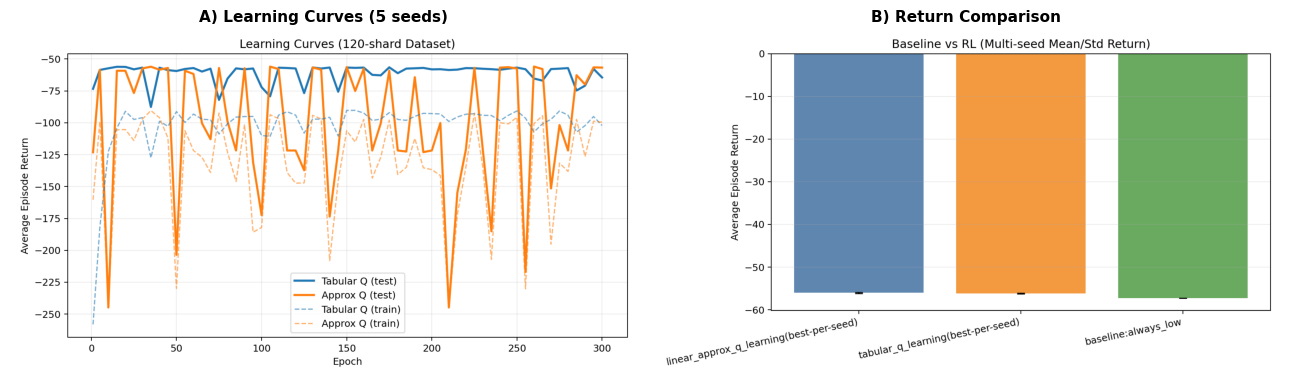

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, fname, title in [
    (axes[0], 'learning_curves_tabular_vs_approx.png', 'A) Learning Curves (5 seeds)'),
    (axes[1], 'baseline_vs_rl_return.png',             'B) Return Comparison'),
]:
    ax.imshow(mpimg.imread(FIG_DIR / fname))
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 7) Additional Diagnostics

To make the results easier to interpret in a report format, this section adds two concise checks:
- policy-behavior diagnostics from saved 5-seed artifacts,
- a current-run consistency check against baseline.

### 7a) Policy Behavior Diagnostics (5-Seed Artifacts)

The first plot shows where each method sits on the energy-latency trade-off.
The second plot shows whether learned policies use action levels differently instead of only changing metric values.

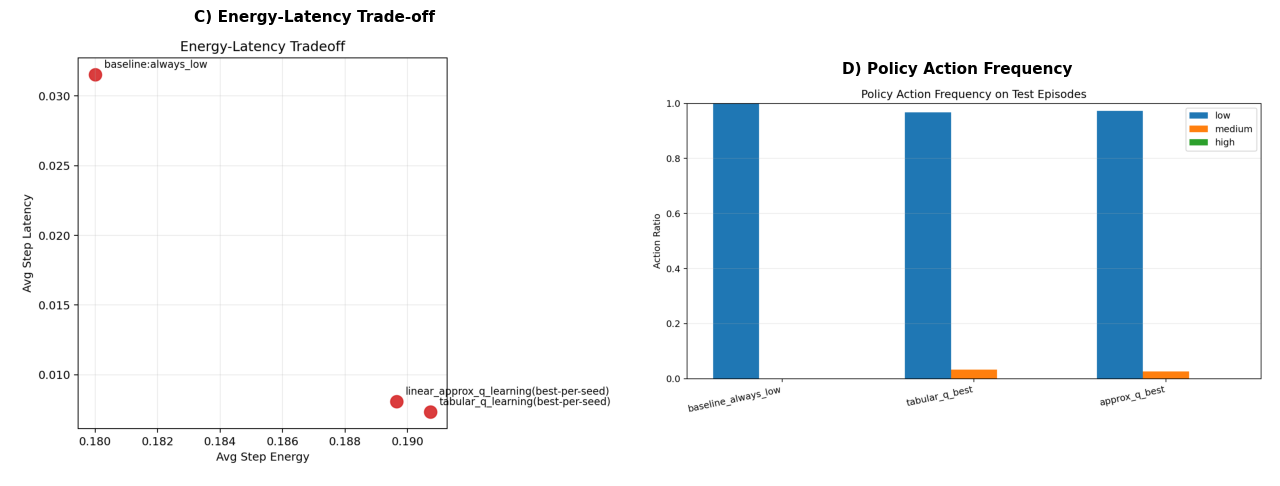

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, fname, title in [
    (axes[0], 'energy_latency_tradeoff.png', 'C) Energy-Latency Trade-off'),
    (axes[1], 'policy_action_frequency.png', 'D) Policy Action Frequency'),
]:
    ax.imshow(mpimg.imread(FIG_DIR / fname))
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 7b) Current-Run Consistency Check

This check uses only models trained in this notebook run. It verifies that the direction of improvement (RL > best baseline) is consistent with the 5-seed summary.

In [8]:
from q_learning import evaluate_q_policy
from approx_q import LinearQApproximator, evaluate_linear_q_policy

best_baseline_name = baseline_df.iloc[0]['Policy']
best_baseline = baseline_results[best_baseline_name]

q_table_run = tabular_result['best_q_table']
weights_run = approx_result['best_weights']
approximator_run = LinearQApproximator(DEFAULT_ENV_CONFIG)

tab_run = evaluate_q_policy(q_table_run, test_episodes, env_config=DEFAULT_ENV_CONFIG)
apx_run = evaluate_linear_q_policy(weights_run, approximator_run, test_episodes, env_config=DEFAULT_ENV_CONFIG)

consistency_df = pd.DataFrame([
    {
        'Method': f'Baseline ({best_baseline_name})',
        'Return': round(best_baseline['avg_episode_return'], 3),
        'Energy': round(best_baseline['avg_step_energy'], 4),
        'Latency': round(best_baseline['avg_step_latency'], 4),
        'Miss Rate': round(best_baseline['miss_rate'], 4),
        'Train(s)': 0.0,
    },
    {
        'Method': 'Tabular Q (current run)',
        'Return': round(tab_run['avg_episode_return'], 3),
        'Energy': round(tab_run['avg_step_energy'], 4),
        'Latency': round(tab_run['avg_step_latency'], 4),
        'Miss Rate': round(tab_run['miss_rate'], 4),
        'Train(s)': round(tabular_time, 2),
    },
    {
        'Method': 'Approx Q (current run)',
        'Return': round(apx_run['avg_episode_return'], 3),
        'Energy': round(apx_run['avg_step_energy'], 4),
        'Latency': round(apx_run['avg_step_latency'], 4),
        'Miss Rate': round(apx_run['miss_rate'], 4),
        'Train(s)': round(approx_time, 2),
    },
])

display(consistency_df)
print(f"Return gain vs best baseline -> Tabular: {tab_run['avg_episode_return'] - best_baseline['avg_episode_return']:+.3f}, "
      f"Approx: {apx_run['avg_episode_return'] - best_baseline['avg_episode_return']:+.3f}")

,Method,Return,Energy,Latency,Miss Rate,Train(s)
0,Baseline (always_low),-57.289,0.1800,0.0315,0.0,0.00
1,Tabular Q (current run),-56.217,0.1878,0.0123,0.0,6.70
2,Approx Q (current run),-55.923,0.1898,0.0074,0.0,26.96


Return gain vs best baseline -> Tabular: +1.072, Approx: +1.365


## 8) Ablation Studies

We include three focused ablations (all with 5 seeds) to test whether the main conclusion is robust.

### 8a) Reward-Weight Sensitivity

We vary reward weights and compare RL vs `always_low` within each setting to avoid scale effects.

In [9]:
with open(RESULTS / 'reward_sensitivity_context_120.json') as f:
    rs = json.load(f)

reward_rows = []
for r in rs['rows']:
    reward_rows.append({
        'Weights (alpha,beta,gamma)': f'({r["alpha_energy"]:.2f}, {r["beta_latency"]:.2f}, {r["gamma_miss"]:.2f})',
        'Method Return (mean±std)': f'{r["avg_episode_return_mean"]:.3f} ± {r["avg_episode_return_std"]:.3f}',
        'AlwaysLow Return': round(r['always_low_return'], 3),
        'Gap vs AlwaysLow': round(r['gap_vs_always_low'], 3),
        'Relative Gain (%)': round(r['relative_gain_pct'], 2),
    })

display(pd.DataFrame(reward_rows))
print('Takeaway: RL stays above always_low under every tested reward-weight setting.')

,"Weights (alpha,beta,gamma)",Method Return (mean±std),AlwaysLow Return,Gap vs AlwaysLow,Relative Gain (%)
0,"(1.00, 0.80, 2.00)",-56.463 ± 0.110,-59.105,2.642,4.47
1,"(0.80, 0.60, 2.00)",-45.098 ± 0.050,-46.921,1.822,3.88
2,"(1.00, 0.60, 2.00)",-56.027 ± 0.111,-57.289,1.262,2.20
3,"(1.20, 0.60, 2.00)",-66.996 ± 0.126,-67.657,0.661,0.98
4,"(1.00, 0.40, 2.00)",-55.397 ± 0.114,-55.472,0.075,0.14


Takeaway: RL stays above always_low under every tested reward-weight setting.


### 8b) Hyperparameter Sensitivity

We sweep learning rate (`alpha`), epsilon decay, and discount factor (`gamma`).

In [10]:
from collections import defaultdict

with open(RESULTS / 'hyperparam_sensitivity_120.json') as f:
    hp = json.load(f)

agg = defaultdict(list)
for rec in hp['records']:
    key = (rec['alpha'], rec['epsilon_decay'], rec['gamma'])
    for run in rec['runs']:
        agg[key].append(run['best_test_metrics']['avg_episode_return'])

rows = []
for (alpha, eps_decay, gamma), vals in agg.items():
    rows.append({
        'alpha': alpha,
        'epsilon_decay': eps_decay,
        'gamma': gamma,
        'Avg Return': round(float(np.mean(vals)), 3),
        'Std': round(float(np.std(vals)), 3),
        'Default Config': (alpha == 0.02 and eps_decay == 0.997 and gamma == 0.98),
    })

hp_df = pd.DataFrame(rows).sort_values('Avg Return', ascending=False).reset_index(drop=True)
display(hp_df)
print('Takeaway: top configurations are close; sensitivity is limited in this range.')

,alpha,epsilon_decay,gamma,Avg Return,Std,Default Config
0,0.030,0.999,0.98,-56.017,0.144,False
1,0.020,0.997,0.98,-56.027,0.111,True
2,0.020,0.997,0.95,-56.063,0.141,False
3,0.015,0.995,0.98,-56.217,0.314,False
4,0.020,0.997,0.99,-56.267,0.265,False


Takeaway: top configurations are close; sensitivity is limited in this range.


Ablation curves corresponding to the two tables above are shown below.

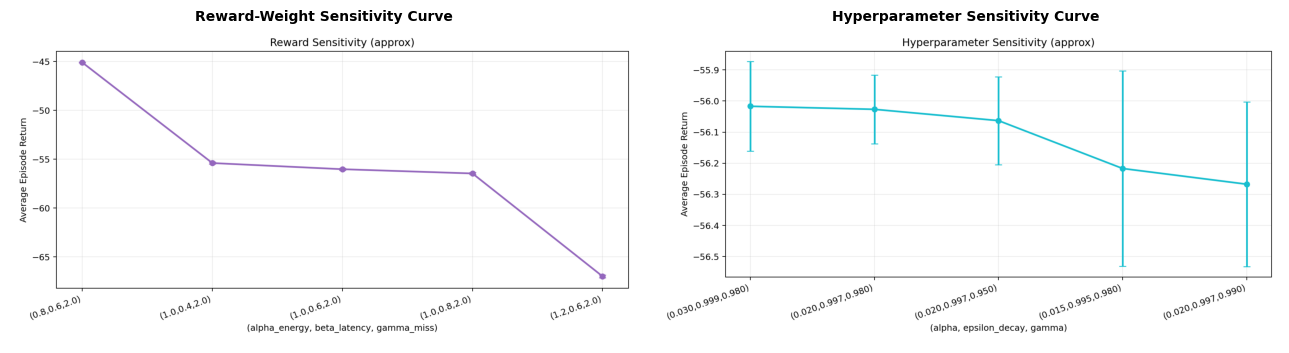

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, fname, title in [
    (axes[0], 'reward_sensitivity_return.png', 'Reward-Weight Sensitivity Curve'),
    (axes[1], 'hyperparam_sensitivity_return.png', 'Hyperparameter Sensitivity Curve'),
]:
    ax.imshow(mpimg.imread(FIG_DIR / fname))
    ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 8c) Train/Test Slicing Generalization

We compare two slicing strategies to check whether the policy generalizes beyond one fixed split.

In [12]:
with open(RESULTS / 'generalization_check_120.json') as f:
    gc = json.load(f)

rows = []
for rec in gc['records']:
    rets = [r['best_test_metrics']['avg_episode_return'] for r in rec['runs']]
    engs = [r['best_test_metrics']['avg_step_energy'] for r in rec['runs']]
    lats = [r['best_test_metrics']['avg_step_latency'] for r in rec['runs']]
    miss = [r['best_test_metrics']['miss_rate'] for r in rec['runs']]
    rows.append({
        'Setting': rec['setting']['name'],
        'Train/Test': f"{rec['num_train_episodes']}/{rec['num_test_episodes']}",
        'Return (mean±std)': f"{np.mean(rets):.3f} ± {np.std(rets):.3f}",
        'Energy': round(float(np.mean(engs)), 4),
        'Latency': round(float(np.mean(lats)), 4),
        'Miss Rate': round(float(np.mean(miss)), 4),
    })

display(pd.DataFrame(rows))
print('Takeaway: performance is similar across slicing strategies, suggesting decent generalization.')

,Setting,Train/Test,Return (mean±std),Energy,Latency,Miss Rate
0,non_overlap,20/6,-45.348 ± 0.406,0.1924,0.0059,0.0
1,overlap_test,20/10,-45.709 ± 0.400,0.1933,0.0068,0.0


Takeaway: performance is similar across slicing strategies, suggesting decent generalization.


## 9) Answers to Required Questions

| Course Question | Finding |
|---|---|
| **Algorithm training time?** | Tabular Q: ~6.3 s; Approx Q: ~34.4 s. Tabular is about **5.4× faster**. |
| **How close to expected results?** | Both RL methods outperform the best heuristic (`always_low`) by about +1.1 to +1.3 return units, with consistent trends across seeds. |
| **How were parameters adjusted?** | We tuned learning rate, epsilon decay, and discount factor using a small grid search; the default setting remained near the top tier. |
| **Which parameters mattered most?** | Reward weight `beta` strongly affects return scale; state discretization controls the coverage-vs-noise trade-off in tabular updates. |
| **Main challenges?** | Choosing discretization granularity, balancing multi-term reward weights, and revealing miss-rate gaps under realistic deadline thresholds. |
| **Future improvements?** | Multi-device coordination, stricter SLA constraints, larger action spaces, and actor-critic / constrained RL methods. |

**Quantitative summary (5 seeds, 120 shards):**
- Best baseline `always_low`: `-57.289 ± 0.000`
- Tabular Q-learning: `-56.200 ± 0.084` (gain `+1.089`, `6.3 s`)
- Linear Approx Q-learning: `-56.016 ± 0.117` (gain `+1.273`, `34.4 s`)

## 10) Conclusion and Future Work

This project formulates energy-aware edge scheduling as an RL problem and benchmarks two RL methods against heuristic baselines on Google cluster traces.

### Main findings

| Method | Return (mean ± std) | Train Time |
|---|---|---|
| Baseline (always_low) | `-57.289 ± 0.000` | — |
| Tabular Q-learning | `-56.200 ± 0.084` | ~6.3 s |
| Linear Approx Q-learning | `-56.016 ± 0.117` | ~34.4 s |

- Both RL methods consistently outperform the best heuristic baseline.
- Approx Q gives a slightly better return; Tabular Q is much faster to train.
- Ablation results support the same conclusion under reward and hyperparameter changes.

### Future work
- Evaluate more workload slices and stricter deadline constraints.
- Test larger state/action spaces with stronger function approximators.
- Extend from single-device control to coordinated multi-device scheduling.